In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import heapq

In [2]:
def PlotGraph(G):
    pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(8, 6))

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=1000,
        node_color='lightblue',
        font_size=8,
        font_weight='bold',
        edge_color='gray',
        width=0.8,
        alpha=0.8
    )

    edge_labels = {}
    for u, v, data in G.edges(data=True):
        w = data.get('weight', '')
        if (u, v) in edge_labels:
            edge_labels[(u, v)] += f",{str(w)}"
        else:
            edge_labels[(u, v)] = str(w)

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    plt.show()


## 1. First part (mandatory) : algorithms on graphs using NetworkX

#### 1. How do you transform the graph of ”Ticket to ride” into a simple graph ? Apply this operation to transform it into a simple graph. From now on, we will refer to this transformed graph for the ”Ticket to ride” network.

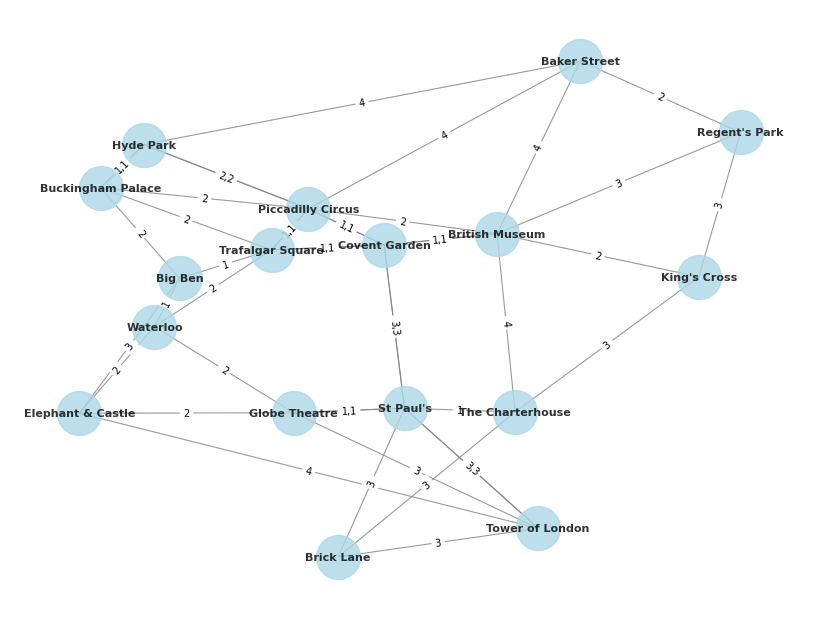

In [3]:
Gt = nx.read_graphml("ticket_to_ride_board_london.graphml")
PlotGraph(Gt)

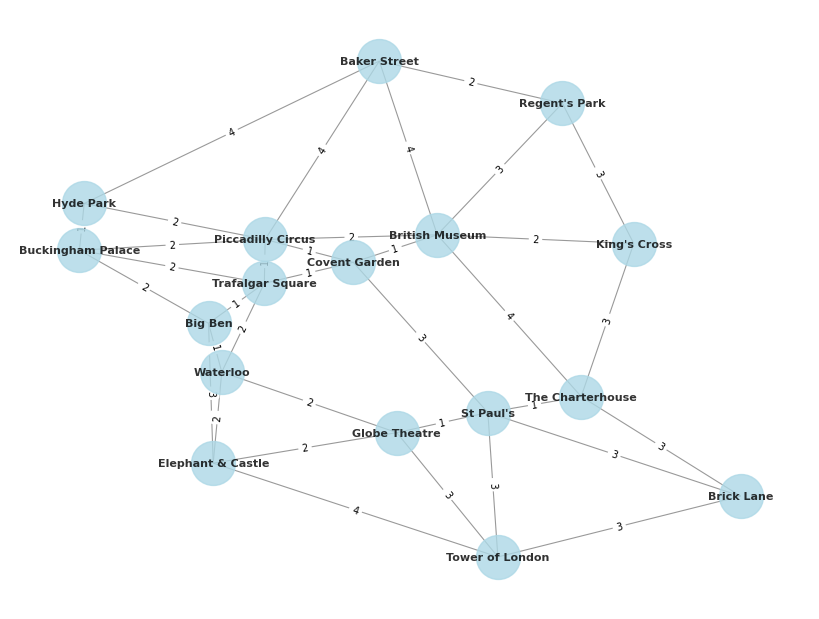

In [4]:
Gt_simple = nx.Graph()
for u, v, data in Gt.edges(data=True):
    if not Gt_simple.has_edge(u, v):
        Gt_simple.add_edge(u, v, **data)

PlotGraph(Gt_simple)

#### 2. Apply Depth First Search (DFS) graph traversal algorithm on the ”Ticket to ride” graph, starting from the ”British Museum” node. Do the same now starting from the ”Globe Theatre” node.

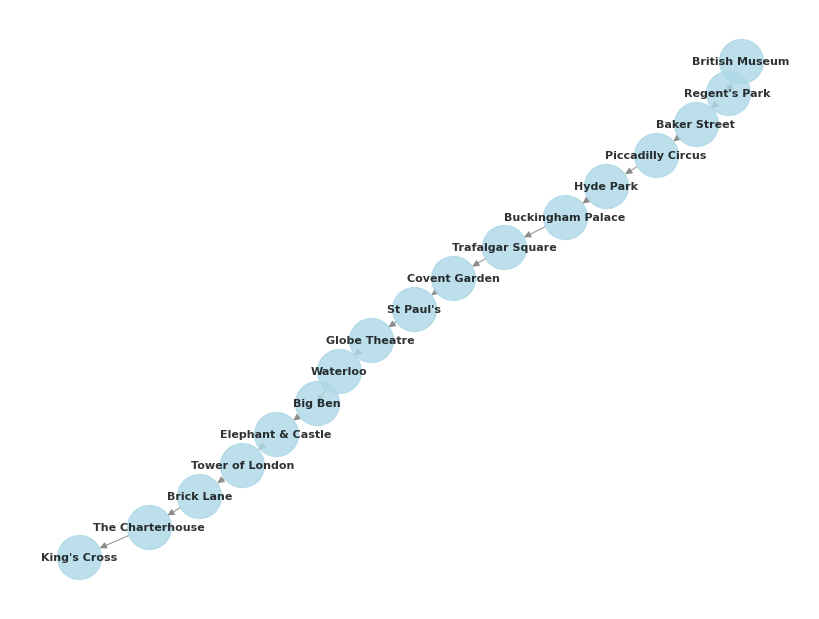

In [5]:
T2 = nx.dfs_tree(Gt_simple, source="British Museum")

list(T2.edges())

PlotGraph(T2)

[('Globe Theatre', 'Waterloo'), ('Waterloo', 'Trafalgar Square'), ('Trafalgar Square', 'Piccadilly Circus'), ('Piccadilly Circus', 'Baker Street'), ('Baker Street', "Regent's Park"), ("Regent's Park", "King's Cross"), ("King's Cross", 'The Charterhouse'), ('The Charterhouse', 'British Museum'), ('British Museum', 'Covent Garden'), ('Covent Garden', "St Paul's"), ("St Paul's", 'Tower of London'), ('Tower of London', 'Brick Lane'), ('Tower of London', 'Elephant & Castle'), ('Elephant & Castle', 'Big Ben'), ('Big Ben', 'Buckingham Palace'), ('Buckingham Palace', 'Hyde Park')]


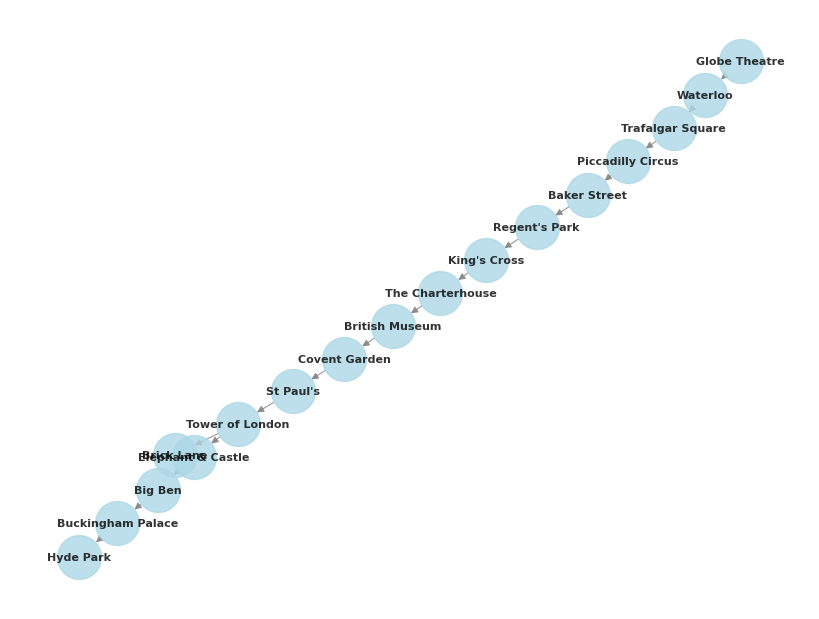

In [6]:
T3 = nx.dfs_tree(Gt_simple, source="Globe Theatre")

print(list(T3.edges()))

PlotGraph(T3)

### 3. Determine the shortest path between the nodes ”Seattle” and ”Santo Domingo” in the ”Pandemic” graph. Check the result by applying Dijkstra’s algorithm by hand.

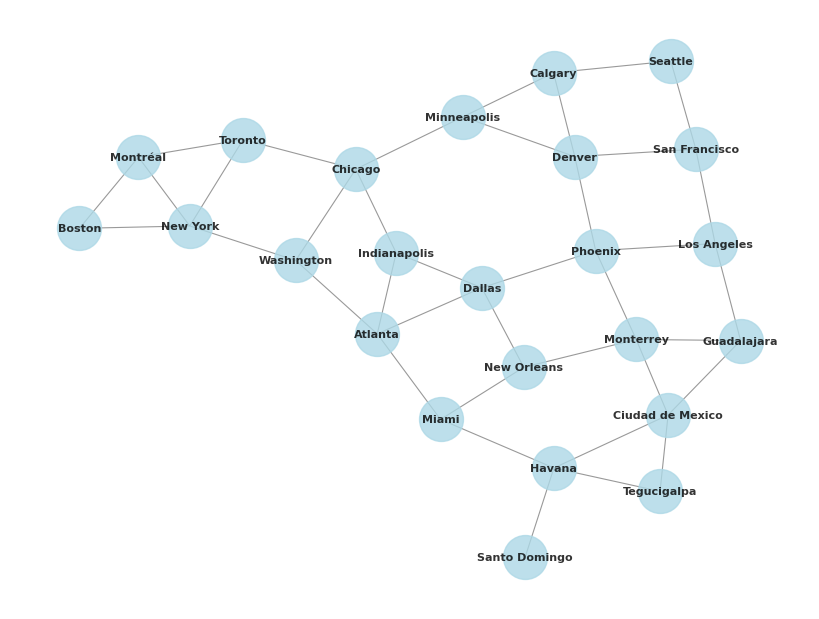

In [7]:
Gp = nx.read_graphml("pandemic_board_us.graphml")

PlotGraph(Gp)

In [8]:
p = nx.shortest_path(Gp, source="Seattle", target="Santo Domingo", weight=None, method='dijkstra')
print(p)

['Seattle', 'San Francisco', 'Los Angeles', 'Guadalajara', 'Ciudad de Mexico', 'Havana', 'Santo Domingo']


<div>
<img src="dijkstra.jpg" width="500"/>
</div>



#### 4. Apply the appropriate NetworkX function to determine the minimum-weight spanning tree of the two graphs. For each graph, is there a single minimum-weight spanning tree ? Check your results by applying Prim’s and Kruskal’s algorithms by hand.

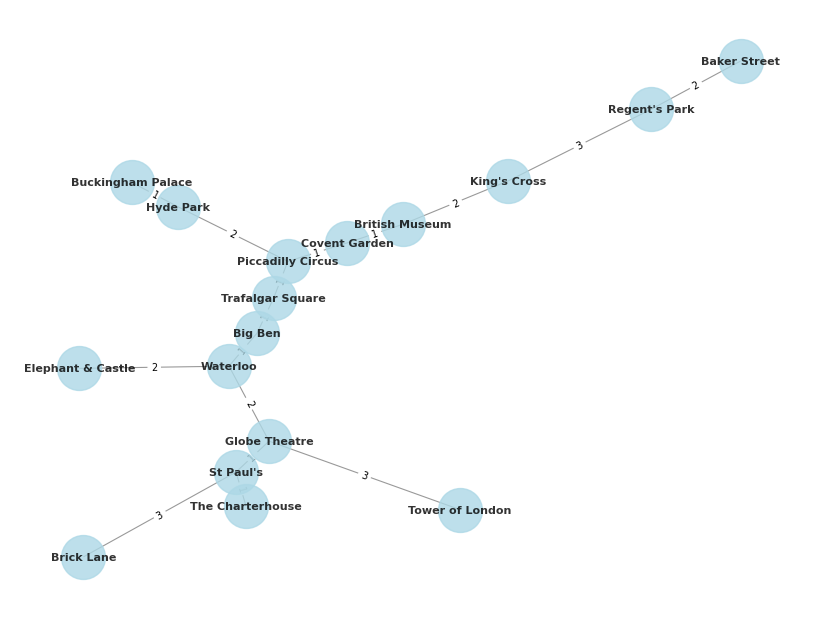

In [9]:
Tp = nx.minimum_spanning_tree(Gt)
PlotGraph(Tp)

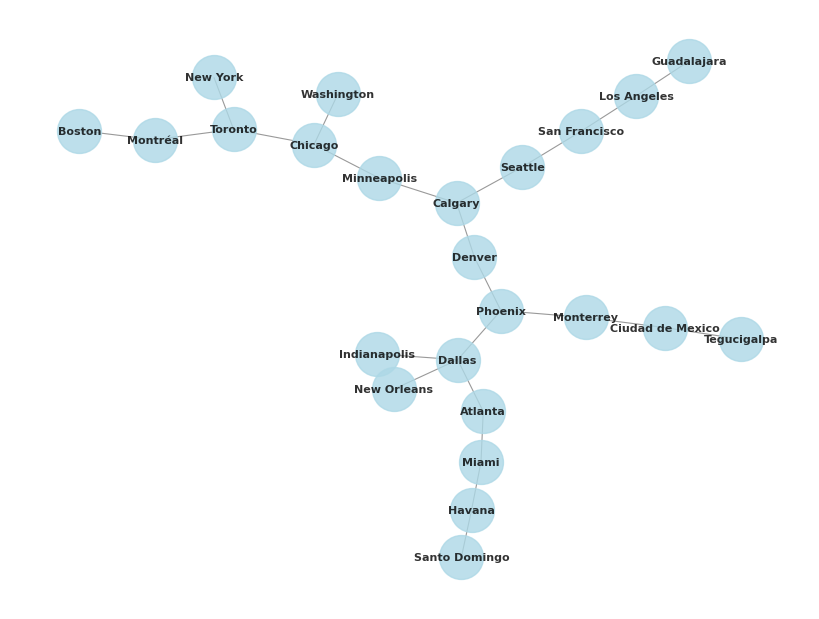

In [10]:
Tp = nx.minimum_spanning_tree(Gp)
PlotGraph(Tp)

<div>
<img src="prim.jpg" width="500"/>
</div>


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    A graph can have multiple minimum spanning trees, because edges with equal value may cause the different tree possibilities. As confirmation, the nx solution and the two handwritten solutions are different from each other, but equally correct. 
  </p>
</div>

## 2 Second part (optional) : implementation of algorithms on graphs with Python

In [ ]:

def Depth_First_Search(graph, start):
    visited = set()
    order = []

    def _dfs(u):
        visited.add(u)
        order.append(u)
        for v in graph.neighbors(u):
            if v not in visited:
                _dfs(v)

    _dfs(start)
    return order

In [12]:
start_node = "British Museum"
dfs_order = Depth_First_Search(Gt_simple, start_node)
print("DFS traversal order starting at", start_node, ":\n", dfs_order)

DFS traversal order starting at British Museum :
 ['British Museum', "Regent's Park", 'Baker Street', 'Piccadilly Circus', 'Hyde Park', 'Buckingham Palace', 'Trafalgar Square', 'Covent Garden', "St Paul's", 'Globe Theatre', 'Waterloo', 'Big Ben', 'Elephant & Castle', 'Tower of London', 'Brick Lane', 'The Charterhouse', "King's Cross"]


In [13]:
def dijkstra(graph, source):
    # Initialize distances
    dist = {node: float('inf') for node in graph.nodes}
    prev = {node: None for node in graph.nodes}
    dist[source] = 0

    # Min-heap priority queue
    pq = [(0, source)]

    while pq:
        current_dist, u = heapq.heappop(pq)

        # Skip outdated queue entries
        if current_dist > dist[u]:
            continue

        for v in graph.neighbors(u):
            # Edge weight (default to 1 if not provided)
            weight = graph[u][v].get('weight', 1)
            alt = dist[u] + weight

            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u
                heapq.heappush(pq, (alt, v))

    return dist, prev

In [14]:
source_node = "Seattle"
distances, predecessors = dijkstra(Gp, source_node)
print("Shortest distances from", source_node, ":\n", distances)

Shortest distances from Seattle :
 {'Calgary': 1, 'Seattle': 0, 'San Francisco': 1, 'Denver': 2, 'Minneapolis': 2, 'Los Angeles': 2, 'Phoenix': 3, 'Dallas': 4, 'Chicago': 3, 'Toronto': 4, 'Montréal': 5, 'Boston': 6, 'New York': 5, 'Washington': 4, 'Indianapolis': 4, 'Atlanta': 5, 'Monterrey': 4, 'New Orleans': 5, 'Miami': 6, 'Guadalajara': 3, 'Ciudad de Mexico': 4, 'Tegucigalpa': 5, 'Havana': 5, 'Santo Domingo': 6}
